<a href="https://colab.research.google.com/github/M4rwaneX/AAA_project/blob/main/projet/projet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

In [36]:
url = "https://raw.githubusercontent.com/M4rwaneX/AAA_project/main/dataset/games.csv"
dataset = pd.read_csv(url)

In [37]:
print(list(dataset.columns))
print(dataset.head(2))
print(dataset.info())

cols_keep = [
    'rated', 'created_at', 'last_move_at', 'turns',
    'white_rating', 'black_rating', 'opening_ply',
    'opening_eco', 'opening_name', 'winner'
]
dataset = dataset[cols_keep].copy()

['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status', 'winner', 'increment_code', 'white_id', 'white_rating', 'black_id', 'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply']
         id  rated    created_at  last_move_at  turns victory_status winner  \
0  TZJHLljE  False  1.504210e+12  1.504210e+12     13      outoftime  white   
1  l1NXvwaE   True  1.504130e+12  1.504130e+12     16         resign  black   

  increment_code  white_id  white_rating   black_id  black_rating  \
0           15+2  bourgris          1500       a-00          1191   
1           5+10      a-00          1322  skinnerua          1261   

                                               moves opening_eco  \
0  d4 d5 c4 c6 cxd5 e6 dxe6 fxe6 Nf3 Bb4+ Nc3 Ba5...         D10   
1  d4 Nc6 e4 e5 f4 f6 dxe5 fxe5 fxe5 Nxe5 Qd4 Nc6...         B00   

                             opening_name  opening_ply  
0        Slav Defense: Exchange Variation            5  
1  Nimzowitsch Defense:

les colonnes que nous allons garder :

['id', 'rated', 'created_at', 'last_move_at', 'turns','increment_code', 'white_id', 'white_rating', 'black_id', 'black_rating', 'opening_eco', 'opening_name', 'opening_ply']

In [38]:
split = skl.model_selection.StratifiedShuffleSplit(n_splits=1,test_size=0.2,random_state=42)
for train_index,test_index in split.split(dataset,dataset["winner"]):
  strat_train_set = dataset.loc[train_index]
  strat_test_set = dataset.loc[test_index]

print(strat_train_set["winner"].value_counts()/len(strat_test_set))

winner
white    1.994267
black    1.815803
draw     0.189432
Name: count, dtype: float64


Text(0, 0.5, 'Fréquence')

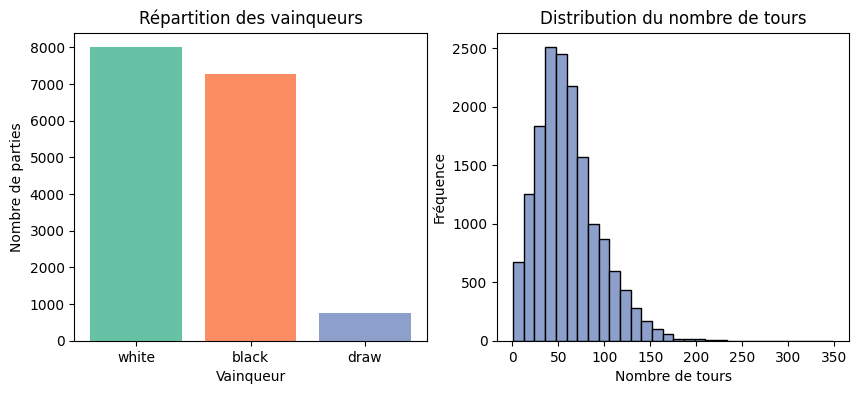

In [54]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
counts_winner = strat_train_set["winner"].value_counts()
plt.bar(counts_winner.index, counts_winner.values, color=['#66c2a5', '#fc8d62', '#8da0cb'])
plt.title("Répartition des vainqueurs")
plt.xlabel("Vainqueur")
plt.ylabel("Nombre de parties")
plt.subplot(1,2,2)
plt.hist(strat_train_set["turns"], bins=30, color="#8da0cb", edgecolor="black")
plt.title("Distribution du nombre de tours")
plt.xlabel("Nombre de tours")
plt.ylabel("Fréquence")

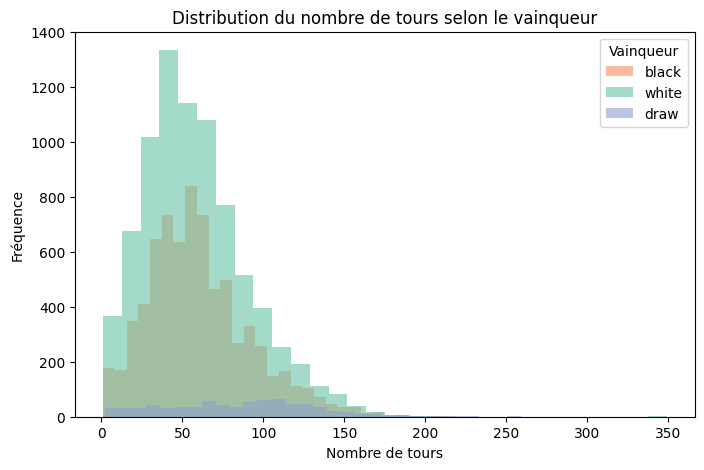

In [56]:
plt.figure(figsize=(8,5))
winners = strat_train_set["winner"].unique()
colors = {"white": "#66c2a5", "black": "#fc8d62", "draw": "#8da0cb"}

for w in winners:
    subset = strat_train_set[strat_train_set["winner"] == w]
    plt.hist(subset["turns"], bins=30, alpha=0.6, label=w, color=colors.get(w, "gray"))

plt.title("Distribution du nombre de tours selon le vainqueur")
plt.xlabel("Nombre de tours")
plt.ylabel("Fréquence")
plt.legend(title="Vainqueur")
plt.show()


In [45]:
cols_numeric = ['rated', 'created_at', 'last_move_at', 'turns',
                'white_rating', 'black_rating', 'opening_ply']

cols_categorical = ['opening_eco', 'opening_name']


preprocessor = skl.compose.ColumnTransformer(
    transformers=[
        ('num', skl.preprocessing.StandardScaler(), cols_numeric),
        ('cat', skl.preprocessing.OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cols_categorical)
    ],
    remainder='drop'
)

pipeline = skl.pipeline.Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', skl.ensemble.RandomForestClassifier())
])

In [49]:
x_train = strat_train_set.drop("winner", axis=1, errors='ignore')
y_train = strat_train_set["winner"]

x_test = strat_test_set.drop("winner", axis=1, errors='ignore')
y_test = strat_test_set["winner"]

cv = skl.model_selection.StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = skl.model_selection.cross_val_score(pipeline, x_train, y_train, cv=cv, scoring='accuracy')

print(f"\nAccuracy moyenne (CV 5 folds) : {cv_scores.mean():.2%} ± {cv_scores.std():.2%}")

pipeline.fit(x_train, y_train)
results = pipeline.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found u


Accuracy moyenne (CV 5 folds) : 62.85% ± 0.72%


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [50]:
y_test = strat_test_set["winner"]

score = pipeline.score(x_test, y_test)
print(f"Précision : {score:.2%}")

print(skl.metrics.classification_report(y_test, results))

print(skl.metrics.confusion_matrix(y_test, results))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Précision : 64.18%
              precision    recall  f1-score   support

       black       0.63      0.61      0.62      1822
        draw       0.69      0.12      0.20       190
       white       0.65      0.72      0.68      2000

    accuracy                           0.64      4012
   macro avg       0.66      0.48      0.50      4012
weighted avg       0.64      0.64      0.63      4012

[[1119    6  697]
 [  91   22   77]
 [ 562    4 1434]]
